# Label Shift

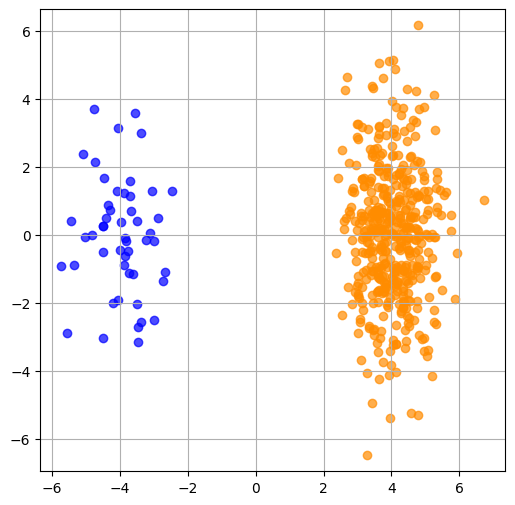

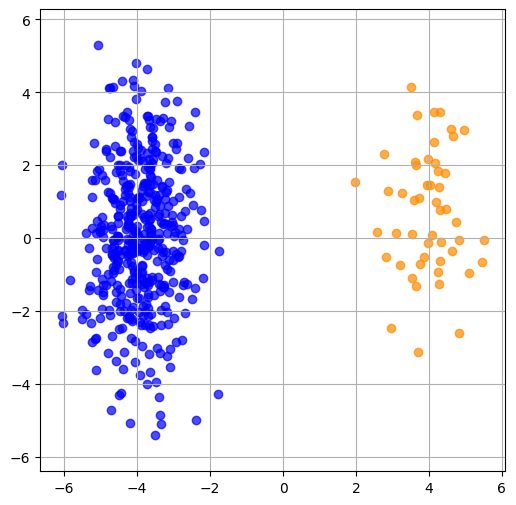

In [11]:
# @title Visualize Two Gaussians (Vertically Elongated) with Different Mixture Weights

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Vertically stretched covariance (tall ellipses)
cov_vertical = np.array([[0.5, 0.0],
                         [0.0, 4.0]])

# Class parameters
mean_orange = np.array([4, 0])
mean_blue   = np.array([-4, 0])

def sample_gaussians(n_total, weight_orange):
    n_orange = int(n_total * weight_orange)
    n_blue = n_total - n_orange

    X_orange = np.random.multivariate_normal(mean_orange, cov_vertical, n_orange)
    X_blue = np.random.multivariate_normal(mean_blue, cov_vertical, n_blue)

    X = np.vstack([X_orange, X_blue])
    y = np.array([0]*n_orange + [1]*n_blue)

    return X, y

def plot_gaussians(X, y, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='#0000FF', alpha=0.7)
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='#FF8C00', alpha=0.7)
    plt.title(title)
    plt.axis('equal')
    plt.grid(True)
    plt.show()

# Figure 1: Orange class dominates
X1, y1 = sample_gaussians(n_total=500, weight_orange=0.9)
plot_gaussians(X1, y1, "")

# Figure 2: Blue class dominates
X2, y2 = sample_gaussians(n_total=500, weight_orange=0.1)
plot_gaussians(X2, y2, "")

# Covariate Shift (Regression)

Chosen alpha: 0.1 (Val MSE = 2535679.5256)


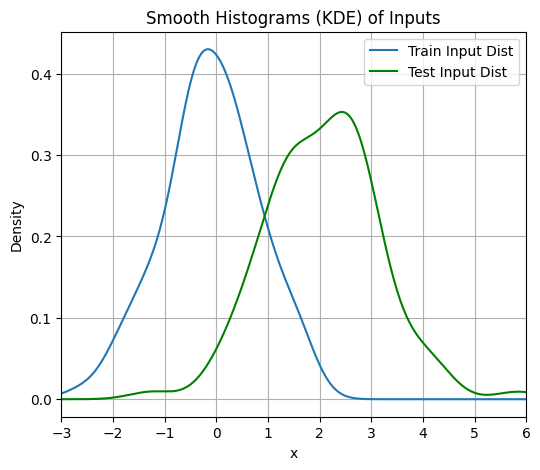

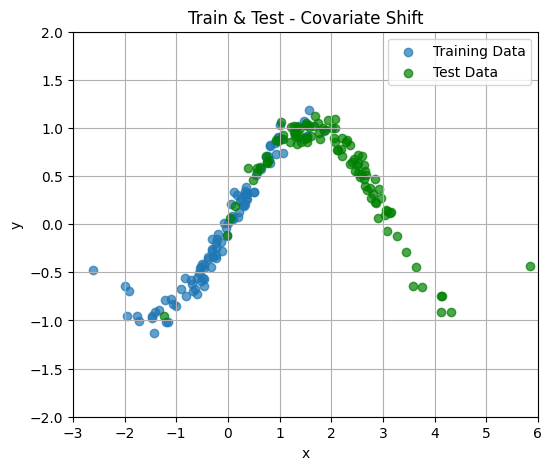

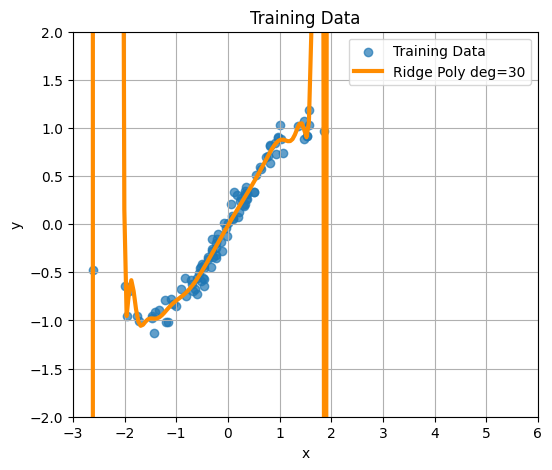

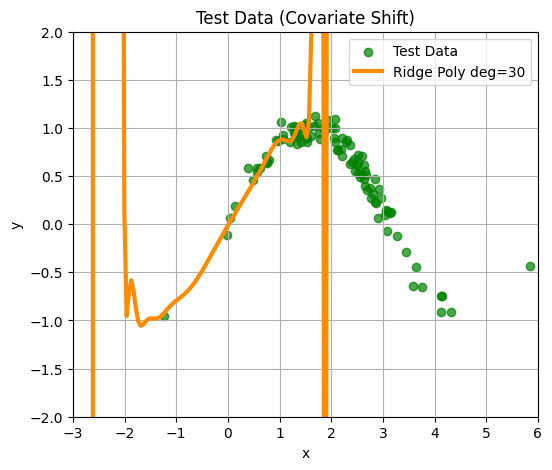

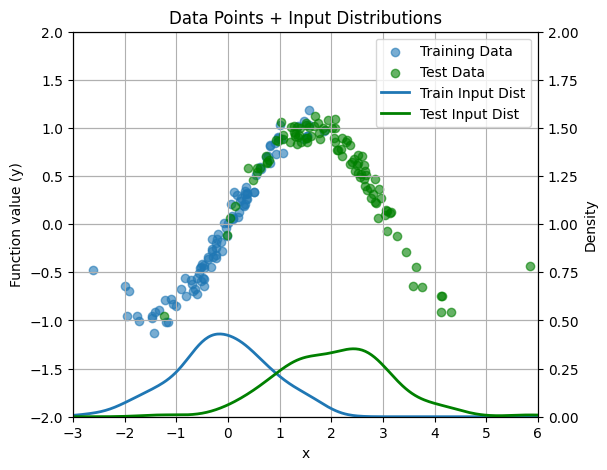

In [47]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# For smooth histogram (KDE)
from scipy.stats import gaussian_kde

# Set random seed for reproducibility
np.random.seed(42)

palette = {
    "Blue": "#1f77b4",
    "Dark Orange": "#ff7f0e",
    "Gray": "#7f7f7f",
    "Orange": "#ff8c00",
    "Purple": "#9467bd"
}

# -----------------------
# 1) Generate training data
# -----------------------
n_train = 100
X_train = np.random.normal(0, 1, n_train).reshape(-1, 1)
y_train = np.sin(X_train).ravel() + np.random.normal(0, 0.1, n_train)

# -----------------------
# 2) Generate test data with covariate shift
# -----------------------
n_test = 100
X_test = np.random.normal(2, 1, n_test).reshape(-1, 1)
y_test = np.sin(X_test).ravel() + np.random.normal(0, 0.1, n_test)

# -----------------------
# 3) Create polynomial features
# -----------------------
degree = 30
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

# -----------------------
# 4) Split training data into train_sub and validation
#    (all from the same source distribution)
# -----------------------
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_poly, y_train, test_size=0.2, random_state=42
)

# -----------------------
# 5) Hyperparameter search for L2 regularization (Ridge)
# -----------------------
alphas = [1e-4, 1e-3, 1e-2, 1e-1]
best_alpha = None
best_val_mse = float("inf")

for alpha in alphas:
    model_temp = Ridge(alpha=alpha)
    model_temp.fit(X_train_sub, y_train_sub)
    y_val_pred = model_temp.predict(X_val)
    val_mse = mean_squared_error(y_val, y_val_pred)
    if val_mse < best_val_mse:
        best_val_mse = val_mse
        best_alpha = alpha

print(f"Chosen alpha: {best_alpha} (Val MSE = {best_val_mse:.4f})")

# -----------------------
# 6) Retrain on entire training set with best_alpha
# -----------------------
model = Ridge(alpha=best_alpha)
model.fit(X_train_poly, y_train)

# -----------------------
# 7) Predictions and MSE
# -----------------------
y_train_pred = model.predict(X_train_poly)
y_test_pred  = model.predict(X_test_poly)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

# -----------------------
# 8) Plotting
# -----------------------
x_min, x_max = -3, 6
y_min, y_max = -2, 2

# Create a smooth curve over a range that covers both train and test
X_plot = np.linspace(x_min, x_max, 200).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
y_plot = model.predict(X_plot_poly)

# --------------------------------------------------------
# Figure 0: Smooth Histograms (KDE) of the input distributions
# --------------------------------------------------------
plt.figure(figsize=(6, 5))
xs = np.linspace(x_min, x_max, 300)
kde_train = gaussian_kde(X_train.ravel())
kde_test  = gaussian_kde(X_test.ravel())

plt.plot(xs, kde_train(xs), color=palette["Blue"], label="Train Input Dist")
plt.plot(xs, kde_test(xs), color='green', label="Test Input Dist")
plt.title("Smooth Histograms (KDE) of Inputs")
plt.xlabel("x")
plt.ylabel("Density")
plt.xlim([x_min, x_max])
plt.grid(True)
plt.legend()
plt.show()

# --------------------------------------------------------
# Figure 1: Show all data (train + test) across entire range
# --------------------------------------------------------
plt.figure(figsize=(6, 5))
plt.scatter(X_train, y_train, color=palette["Blue"], alpha=0.7, label='Training Data')
plt.scatter(X_test, y_test, color='green', alpha=0.7, label='Test Data')
plt.title("Train & Test - Covariate Shift")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------------
# Figure 2: Training Data + Model Fit
# --------------------------------------------------------
plt.figure(figsize=(6, 5))
plt.scatter(X_train, y_train, color=palette["Blue"], alpha=0.7, label='Training Data')
plt.plot(X_plot, y_plot, color=palette["Orange"], linewidth=3, label=f'Ridge Poly deg={degree}')
plt.title(f"Training Data")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------------
# Figure 3: Test Data + Model Fit
# --------------------------------------------------------
plt.figure(figsize=(6, 5))
plt.scatter(X_test, y_test, color='green', alpha=0.7, label='Test Data')
plt.plot(X_plot, y_plot, color=palette["Orange"], linewidth=3, label=f'Ridge Poly deg={degree}')
plt.title(f"Test Data (Covariate Shift)")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim([x_min, x_max])
plt.ylim([y_min, y_max])
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------------------
# Figure 4: Overlay both scatter & distribution in a single figure
# --------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(6,5))

# -- Left axis: scatter of train/test
ax1.scatter(X_train, y_train, color=palette["Blue"], alpha=0.6, label='Training Data')
ax1.scatter(X_test, y_test, color='green', alpha=0.6, label='Test Data')
ax1.set_xlabel("x")
ax1.set_ylabel("Function value (y)")
ax1.set_xlim([x_min, x_max])
ax1.set_ylim([y_min, y_max])
ax1.grid(True)

# -- Right axis: KDE lines
ax2 = ax1.twinx()
ax2.plot(xs, kde_train(xs), color=palette["Blue"], label="Train Input Dist", linewidth=2)
ax2.plot(xs, kde_test(xs), color='green', label="Test Input Dist", linewidth=2)
ax2.set_ylabel("Density")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax2.set_ylim(0, 2.0)

plt.title("Data Points + Input Distributions")
plt.show()

Training Accuracy: 1.00
Test Accuracy (Covariate Shift): 0.99


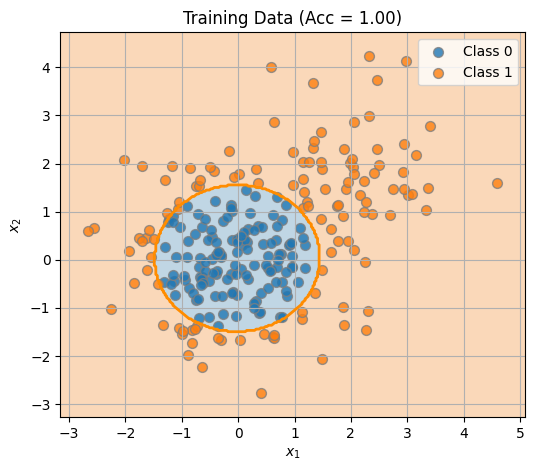

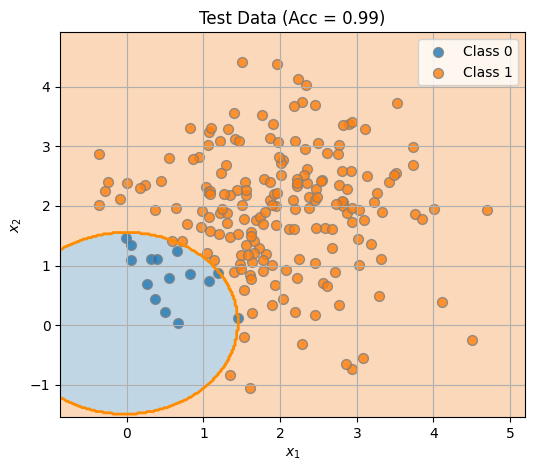

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import PolynomialFeatures

# --- Seed for reproducibility ---
np.random.seed(0)

# --- Sample sizes ---
n_train = 200
n_test  = 200

# --- True decision boundary: circle of radius r ---
def label_circle(X, r=1.5):
    return ((X[:, 0]**2 + X[:, 1]**2) > r**2).astype(int)

# --- Generate training data near the origin ---
X_train_orig = np.random.normal(loc=0.0, scale=1.0, size=(n_train, 2))
y_train_orig = label_circle(X_train_orig)

# --- Generate test data near (2,2) for covariate shift ---
X_test = np.random.normal(loc=2.0, scale=1.0, size=(n_test, 2))
y_test = label_circle(X_test)

# -----------------------------
# (OPTIONAL) Step 2: Augment or Mix Data to Handle Shift
# -----------------------------
# For demonstration, let's augment the original training data with some "shifted" points.
# Typically you might have a small labeled sample from the shifted distribution.
n_extra = 50
X_shifted_labeled = np.random.normal(loc=2.0, scale=1.0, size=(n_extra, 2))
y_shifted_labeled = label_circle(X_shifted_labeled)

X_train = np.vstack([X_train_orig, X_shifted_labeled])
y_train = np.concatenate([y_train_orig, y_shifted_labeled])

# -----------------------------
# Step 3: Polynomial Features for a Nonlinear Boundary
# -----------------------------
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

clf = LogisticRegression()
clf.fit(X_train_poly, y_train)

# --- Predictions and accuracies ---
y_pred_train = clf.predict(X_train_poly)
acc_train = accuracy_score(y_train, y_pred_train)

y_pred_test = clf.predict(X_test_poly)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Training Accuracy: {acc_train:.2f}")
print(f"Test Accuracy (Covariate Shift): {acc_test:.2f}")

from matplotlib.colors import LinearSegmentedColormap

# Example color palette
palette = {
    "Blue": "#1f77b4",
    "Dark Orange": "#ff7f0e",
    "Gray": "#7f7f7f",
    "Orange": "#ff8c00",
    "Purple": "#9467bd"
}

region_cmap = LinearSegmentedColormap.from_list(
    "region_cmap", [palette["Blue"], palette["Dark Orange"]]
)

def plot_decision_regions(model, X, y, title, poly_transformer, 
                          xlim=None, ylim=None):
    """
    model: trained LogisticRegression (or similar)
    X, y: raw data (before polynomial transform)
    title: plot title
    poly_transformer: instance of PolynomialFeatures used in training
    xlim, ylim: optional axis limits for consistency
    """
    # 1) Create a grid
    if xlim is None:
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    else:
        x_min, x_max = xlim

    if ylim is None:
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    else:
        y_min, y_max = ylim

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # 2) Transform grid using the same polynomial features
    grid_poly = poly_transformer.transform(grid_points)
    Z = model.predict(grid_poly).reshape(xx.shape)

    # 3) Plot decision region
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=region_cmap)
    # Optional: draw contour lines for boundary
    plt.contour(xx, yy, Z, levels=[0.5], colors=palette["Orange"], linewidths=2)

    # 4) Scatter points
    for cls, color in zip([0, 1], [palette["Blue"], palette["Dark Orange"]]):
        plt.scatter(X[y == cls, 0], X[y == cls, 1],
                    c=color, edgecolor=palette["Gray"], s=50,
                    label=f"Class {cls}", alpha=0.8)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Visualize on training data ---
plot_decision_regions(clf, X_train, y_train, 
                      title=f"Training Data (Acc = {acc_train:.2f})",
                      poly_transformer=poly)

# --- Visualize on test data ---
plot_decision_regions(clf, X_test, y_test, 
                      title=f"Test Data (Acc = {acc_test:.2f})",
                      poly_transformer=poly)

# Concept Shift

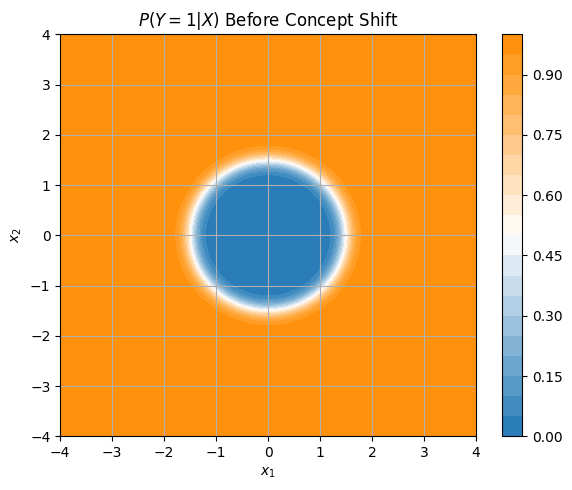

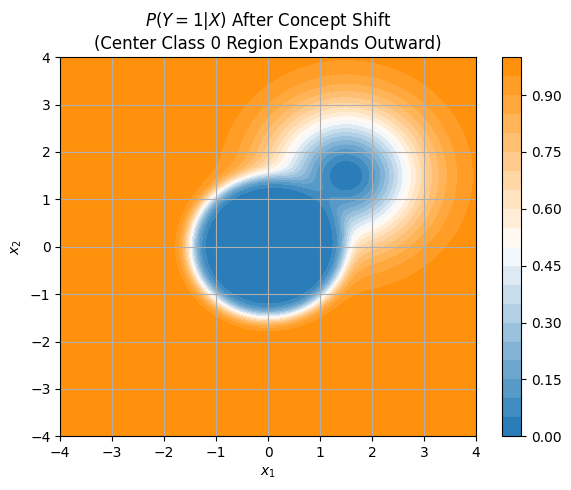

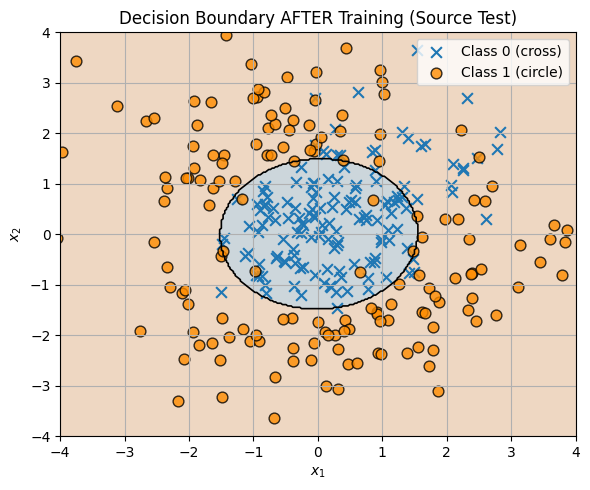

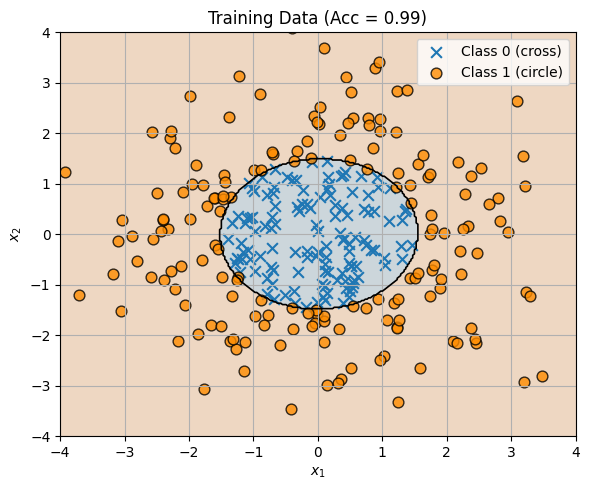

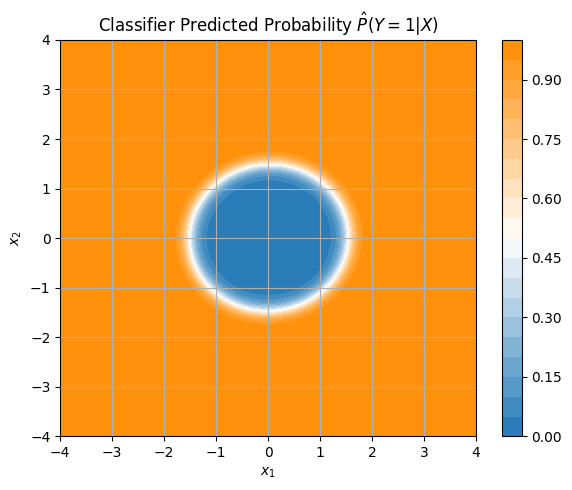

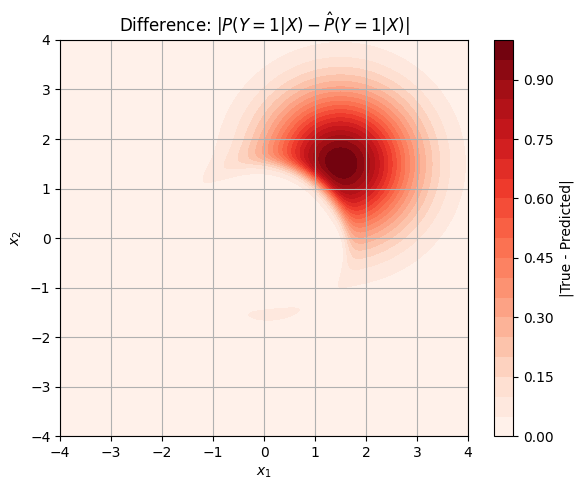

In [9]:
# Full code that generates all requested figures with clear decision boundaries,
# smoothed true conditionals, prediction errors, and training/test overlays

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score, roc_auc_score
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# --- Setup ---
palette = {
    "Blue": "#1f77b4",
    "Dark Orange": "#ff7f0e",
    "Gray": "#7f7f7f",
    "Orange": "#ff8c00",
    "Purple": "#9467bd"
}
conditional_cmap = LinearSegmentedColormap.from_list(
    "conditional_cmap", [palette["Blue"], "white", palette["Orange"]]
)
norm = TwoSlopeNorm(vmin=0.0, vcenter=0.5, vmax=1.0)

xlim = -4, 4
ylim = -4, 4

# Grid setup
xx, yy = np.meshgrid(np.linspace(-4, 4, 300), np.linspace(-4, 4, 300))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# --- True posterior functions ---
def smooth_posterior_before(X, r=1.5, slope=10):
    d = np.sqrt(X[:, 0]**2 + X[:, 1]**2)
    return 1 / (1 + np.exp(-slope * (d - r)))

def smooth_posterior_after_blob_zero(X, r=1.5, slope=10, blob_center=(1.5, 1.5), blob_strength=1.0, blob_width=1.0):
    d = np.sqrt(X[:, 0]**2 + X[:, 1]**2)
    base = 1 / (1 + np.exp(-slope * (d - r)))
    dx, dy = X[:, 0] - blob_center[0], X[:, 1] - blob_center[1]
    dist2 = dx**2 + dy**2
    blob = blob_strength * np.exp(-dist2 / (2 * blob_width**2))
    return np.clip(base * (1 - blob), 0, 1)

# Generate training/test data
np.random.seed(42)
X_train = np.random.normal(0, 1.5, size=(300, 2))
y_train = (np.sqrt(X_train[:, 0]**2 + X_train[:, 1]**2) > 1.5).astype(int)
X_test = np.random.normal(0, 1.5, size=(300, 2))
p_test_true = smooth_posterior_after_blob_zero(X_test)
y_test = np.random.binomial(1, p_test_true)

# Train classifier
poly = PolynomialFeatures(2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
clf = LogisticRegression().fit(X_train_poly, y_train)
y_pred = clf.predict(X_test_poly)
y_proba = clf.predict_proba(X_test_poly)[:, 1]
acc_train = accuracy_score(y_train, clf.predict(X_train_poly))
Z_clf = clf.predict(poly.transform(grid_points)).reshape(xx.shape)
Z_proba = clf.predict_proba(poly.transform(grid_points))[:, 1].reshape(xx.shape)
Z_true = smooth_posterior_after_blob_zero(grid_points).reshape(xx.shape)

# --- Plotting utilities ---
def plot_contour(Z, title, cmap=conditional_cmap, norm=norm, colorbar_label=None):
    plt.figure(figsize=(6, 5))
    cs = plt.contourf(xx, yy, Z, levels=20, cmap=cmap, norm=norm)
    if colorbar_label:
        plt.colorbar(cs, label=colorbar_label)
    else:
        plt.colorbar(cs)
    plt.title(title)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.xlim(*xlim); plt.ylim(*ylim)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_decision_boundary_with_data(X, y, Z, title):
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, levels=1, cmap=LinearSegmentedColormap.from_list("regions", [palette["Blue"], palette["Dark Orange"]]), alpha=0.3)
    plt.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.2)
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c=palette["Blue"], marker='x', s=60, label="Class 0 (cross)")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c=palette["Orange"], marker='o', edgecolor='black', s=60, label="Class 1 (circle)", alpha=0.8)
    plt.title(title)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()
    plt.xlim(*xlim); plt.ylim(*ylim)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Generate all plots ---
plot_contour(smooth_posterior_before(grid_points).reshape(xx.shape), "$P(Y=1|X)$ Before Concept Shift")
plot_contour(Z_true, "$P(Y=1|X)$ After Concept Shift\n(Center Class 0 Region Expands Outward)")
plot_decision_boundary_with_data(X_test, y_test, Z_clf, "Decision Boundary AFTER Training (Source Test)")
plot_decision_boundary_with_data(X_train, y_train, Z_clf, f"Training Data (Acc = {acc_train:.2f})")
plot_contour(Z_proba, "Classifier Predicted Probability $\\hat{P}(Y=1|X)$")
plot_contour(np.abs(Z_true - Z_proba), "Difference: $|P(Y=1|X) - \\hat{P}(Y=1|X)|$", cmap="Reds", colorbar_label="|True - Predicted|")

# Covariate Shift (Classification)

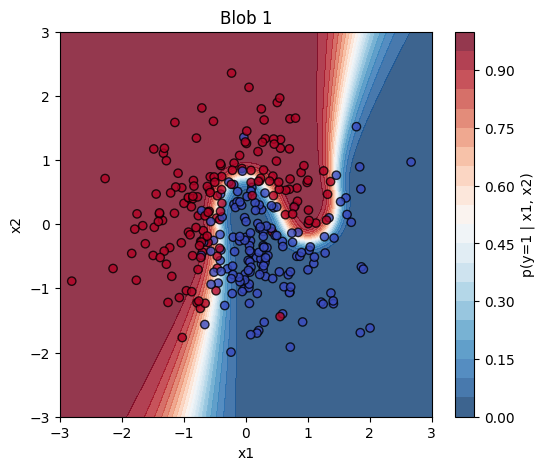

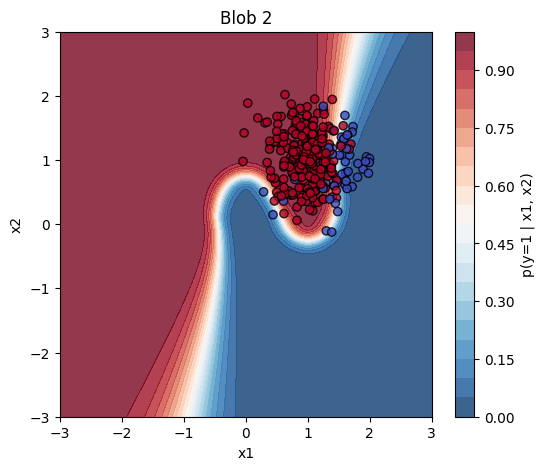

In [ ]:
# %% [code]
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Define parametric arcs (two "moons") in (x1, x2) space
#    ArcA (top), ArcB (bottom)
# -------------------------------
def generate_arcA(num_points=500):
    t = np.linspace(0, np.pi, num_points)
    x1 = np.cos(t)
    x2 = np.sin(t)
    return np.column_stack([x1, x2])

def generate_arcB(num_points=500):
    t = np.linspace(0, np.pi, num_points)
    x1 = 1 - np.cos(t)
    x2 = -np.sin(t) + 0.5
    return np.column_stack([x1, x2])

arcA = generate_arcA()
arcB = generate_arcB()

# -------------------------------
# 2. Define the two-moons class posterior p(y=1|x1,x2)
#    p(y=1|x) = sigmoid(alpha*(distB - distA)),
#    where distA, distB = min distance to each arc.
#    We'll use alpha=7 for a moderately sharp boundary.
# -------------------------------
alpha = 7.0

def distance_to_arc(x1, x2, arc_points):
    dists = np.sqrt((arc_points[:,0] - x1)**2 + (arc_points[:,1] - x2)**2)
    return dists.min()

def two_moons_posterior(x1, x2):
    distA = distance_to_arc(x1, x2, arcA)
    distB = distance_to_arc(x1, x2, arcB)
    return 1.0 / (1.0 + np.exp(-alpha * (distB - distA)))

# -------------------------------
# 3. Generate two blobs with different covariances
#    Blob 1: near [0,0], covariance ~ 0.3
#    Blob 2: near [1,0], covariance ~ half of Blob1 => 0.15
#    => partial overlap near [0.5, 0]
# -------------------------------
np.random.seed(42)

mean_blob1 = np.array([0.0, 0.0])
mean_blob2 = np.array([1.0, 1.0])

cov1_value = 0.75
cov2_value = 0.15

cov_blob1 = np.array([[cov1_value, 0.0],
                      [0.0,       cov1_value]])
cov_blob2 = np.array([[cov2_value, 0.0],
                      [0.0,        cov2_value]])

X_blob1 = np.random.multivariate_normal(mean_blob1, cov_blob1, size=300)
X_blob2 = np.random.multivariate_normal(mean_blob2, cov_blob2, size=300)

def label_with_two_moons(X):
    y = []
    for (x1, x2) in X:
        p = two_moons_posterior(x1, x2)
        label = 1 if np.random.rand() < p else 0
        y.append(label)
    return np.array(y)

y_blob1 = label_with_two_moons(X_blob1)
y_blob2 = label_with_two_moons(X_blob2)

# -------------------------------
# 4. Create a mesh grid for p(y=1|x1,x2)
#    We'll use xlim(-2, 2), ylim(-1, 1.5)
# -------------------------------
xlim = [-3, 3]
ylim = [-3, 3]
num_grid = 200

grid_x1 = np.linspace(xlim[0], xlim[1], num_grid)
grid_x2 = np.linspace(ylim[0], ylim[1], num_grid)
XX1, XX2 = np.meshgrid(grid_x1, grid_x2)

ZZ = np.zeros_like(XX1)
for i in range(num_grid):
    for j in range(num_grid):
        ZZ[i, j] = two_moons_posterior(XX1[i, j], XX2[i, j])

# -------------------------------
# 5. Plot function for overlaying data on the two-moons posterior
# -------------------------------
def plot_distribution_and_labels(X, y, title):
    plt.figure(figsize=(6,5))
    # Probability surface of p(y=1|x1,x2)
    contour = plt.contourf(XX1, XX2, ZZ, levels=20, cmap='RdBu_r', alpha=0.8)
    cbar = plt.colorbar(contour)
    cbar.set_label('p(y=1 | x1, x2)')

    # Scatter data
    plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.8)

    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.show()

# -------------------------------
# 6. Plot each distribution over the same p(y=1|x) heatmap
#    => Covariate shift with partial overlap; Blob1 has twice the variance
# -------------------------------
plot_distribution_and_labels(X_blob1, y_blob1, "Blob 1")
plot_distribution_and_labels(X_blob2, y_blob2, "Blob 2")


import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from torch.utils.data import DataLoader, TensorDataset
import random

# -----------------------------------------
# Original Color Palette
# -----------------------------------------
color_palette = {
    "white": "#FFFFFF",
    "light_gray": "#D3D3D3",
    "gray": "#808080",
    "black": "#000000",
    "green": "#008000",
    "blue": "#0000FF",
    "light_blue": "#ADD8E6",
    "light_light_blue": "#E0FFFF",
    "yellow": "#FFFF00",
    "orange": "#FFA500",
    "dark_orange": "#FF8C00",
    "purple": "#800080",
}

# -----------------------------------------
# Class Colors (2 Classes: Binary Classification)
# -----------------------------------------
class_colors = [
    color_palette["blue"],        # Class 0
    color_palette["dark_orange"]  # Class 1
]

# Fix random seeds for reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)
pl.seed_everything(seed, workers=True)

# If using CUDA
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# -------------------------------
# 1. Prepare Data: Source and Target Distributions
# -------------------------------
X_source_train, X_source_temp, y_source_train, y_source_temp = train_test_split(X_blob1, y_blob1, test_size=0.4, random_state=42)
X_source_val, X_source_test, y_source_val, y_source_test = train_test_split(X_source_temp, y_source_temp, test_size=0.5, random_state=42)
X_target_test, y_target_test = X_blob2, y_blob2

# Convert to PyTorch tensors
X_source_train_tensor = torch.tensor(X_source_train, dtype=torch.float32)
y_source_train_tensor = torch.tensor(y_source_train, dtype=torch.float32).unsqueeze(1)
X_source_val_tensor = torch.tensor(X_source_val, dtype=torch.float32)
y_source_val_tensor = torch.tensor(y_source_val, dtype=torch.float32).unsqueeze(1)
X_source_test_tensor = torch.tensor(X_source_test, dtype=torch.float32)
y_source_test_tensor = torch.tensor(y_source_test, dtype=torch.float32).unsqueeze(1)
X_target_test_tensor = torch.tensor(X_target_test, dtype=torch.float32)
y_target_test_tensor = torch.tensor(y_target_test, dtype=torch.float32).unsqueeze(1)

# Create DataLoader
train_dataset = TensorDataset(X_source_train_tensor, y_source_train_tensor)
val_dataset = TensorDataset(X_source_val_tensor, y_source_val_tensor)
test_dataset = TensorDataset(X_source_test_tensor, y_source_test_tensor)
target_dataset = TensorDataset(X_target_test_tensor, y_target_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
target_loader = DataLoader(target_dataset, batch_size=32, shuffle=False)

# -------------------------------
# 2. Define Lightning Neural Network Model
# -------------------------------
class LightningNeuralNet(pl.LightningModule):
    def __init__(self):
        super(LightningNeuralNet, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.criterion = nn.BCELoss()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return x

    def training_step(self, batch, batch_idx):
        X_batch, y_batch = batch
        outputs = self.forward(X_batch)
        loss = self.criterion(outputs, y_batch)
        return loss
    
    def validation_step(self, batch, batch_idx):
        X_batch, y_batch = batch
        outputs = self.forward(X_batch)
        loss = self.criterion(outputs, y_batch)
        self.log("val_loss", loss, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=0.01)

# -------------------------------
# 3. Train the Model with Validation-based Early Stopping
# -------------------------------
model = LightningNeuralNet()
trainer = pl.Trainer(max_epochs=10000, callbacks=[pl.callbacks.EarlyStopping(monitor="val_loss", patience=100)])
trainer.fit(model, train_loader, val_loader)

# -------------------------------
# 4. Evaluate on Source and Target Test Data
# -------------------------------
model.eval()
with torch.no_grad():
    y_source_test_pred = (model(X_source_test_tensor) > 0.5).numpy().flatten()
    y_target_test_pred = (model(X_target_test_tensor) > 0.5).numpy().flatten()

source_test_acc = accuracy_score(y_source_test, y_source_test_pred)
target_test_acc = accuracy_score(y_target_test, y_target_test_pred)

print(f'Source Test Accuracy: {source_test_acc:.4f}')
print(f'Target Test Accuracy (Covariate Shifted): {target_test_acc:.4f}')

# -------------------------------
# 5. Visualization Functions
# -------------------------------
def plot_decision_boundary(X, y, model, title, show_data=True):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    model.eval()
    with torch.no_grad():
        Z = model(torch.tensor(grid, dtype=torch.float32)).numpy().reshape(xx.shape)
    
    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(class_colors))
    if show_data:
        plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap=ListedColormap(class_colors))
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

# Plot decision boundaries
plot_decision_boundary(X_source_test, y_source_test, model, "Decision Boundary AFTER Training (Source Test)")
plot_decision_boundary(X_target_test, y_target_test, model, "Decision Boundary AFTER Training (Target Test)")
plot_decision_boundary(X_source_test, y_source_test, model, "Decision Boundary AFTER Training", False)